# Per-timestep overlap of preference- and choice-selective units

Per time window, what fraction of **preference-selective** units are **also choice-selective**?
Computed for the whole population and split by region, plotted as mean +/- s.e.m. across the 12 features.

Selectivity comes from the windowed factorial ANOVAs already on disk:

| selectivity | ANOVA `conditions` | `beh_filters` | fracvar term |
|---|---|---|---|
| choice | `["Choice", "Response"]` | `{}` | `x_Choice_comb_time_fracvar` |
| preference | `["BeliefConf", "BeliefPartition"]` | `{"Response":"Correct","Choice":"Chose"}` | `x_BeliefPref_comb_time_fracvar` |

A (unit, feature, window) is called selective if its fracvar exceeds that unit's own shuffle
percentile for that window.

**Why not the `*_99th_window_filter_drift` pickles.** Those are produced by
`scripts/multi_session_analysis/20250606_generate_significant_units.py`, which unions over windows
*and* over events before saving, then writes the same dataframe under both event filenames. They
carry no time axis. `io_utils.read_anova_good_units(args, "all", var)` is the per-window source, and
it also merges against `spike_utils.get_good_subject_units`, so drifting units and bad regions are
already dropped.

**Read the caveats at the bottom before interpreting the numbers.** The headline ratio is
power-dependent in a way that matters for comparing regions.

In [4]:
import sys
sys.path.insert(0, '/src/wcst_decode')
import warnings; warnings.filterwarnings("ignore")

import argparse
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

import utils.io_utils as io_utils
import utils.visualization_utils as visualization_utils
from scripts.anova_analysis.anova_configs import AnovaConfigs
from constants.behavioral_constants import FEATURES
from constants.decoding_constants import REGIONS_OF_INTEREST

plt.rcParams.update({'font.size': 16})

### Setup

In [5]:
SIG_THRESH = "95th"          # "99th" or "95th"
WINDOW_SIZE = 500            # must match the ANOVA runs on disk
EVENTS = ["StimOnset", "FeedbackOnsetLong"]
SUBJECTS = ["SA", "BL"]

# (fracvar term, ANOVA conditions, beh_filters) -- these reconstruct the output dir name
VAR_CONFIGS = {
    "choice": ("Choice",     ["Choice", "Response"],           {}),
    "pref":   ("BeliefPref", ["BeliefConf", "BeliefPartition"], {"Response": "Correct", "Choice": "Chose"}),
}

# get_sig_levels() returns the *highest* level passed, so "95th" means "passed 95th but not 99th".
# A 95th-percentile criterion therefore has to accept both labels.
SIG_LEVELS = {"99th": ["99th"], "95th": ["95th", "99th"]}

EVENT_CONFIG = {
    "StimOnset":         {"ticks": [-0.5, 0, 0.5], "vlines": [-0.5, 0.0], "xlabel": "Time to stimuli appear (s)"},
    "FeedbackOnsetLong": {"ticks": [-1.5, -1, -0.5, 0, 0.5, 1], "vlines": [-0.8, 0.0], "xlabel": "Time to feedback (s)"},
}

### Load per-window selectivity, merge the two variables

In [6]:
def load_selectivity(sub, event, kind):
    """Per (unit, feat, window) significance for one selectivity type."""
    var, conditions, beh_filters = VAR_CONFIGS[kind]
    args = argparse.Namespace(**AnovaConfigs()._asdict())
    args.subject = sub
    args.trial_event = event
    args.conditions = conditions
    args.beh_filters = beh_filters
    args.window_size = WINDOW_SIZE
    # percentile_str="all" keeps every row and adds the `p` column; passing a real percentile
    # instead would apply a *unit-level* criterion (significant in any window -> all rows kept).
    res = io_utils.read_anova_good_units(args, "all", var)
    res = res[["PseudoUnitID", "feat", "WindowStartMilli", "WindowEndMilli",
               "structure_level2_cleaned", "p"]].copy()
    res["sig"] = res["p"].isin(SIG_LEVELS[SIG_THRESH])
    return res.drop(columns="p")


def load_merged():
    keys = ["PseudoUnitID", "feat", "WindowStartMilli", "WindowEndMilli", "structure_level2_cleaned"]
    out = []
    for event in EVENTS:
        for sub in SUBJECTS:
            ch = load_selectivity(sub, event, "choice").rename(columns={"sig": "choice_sig"})
            pr = load_selectivity(sub, event, "pref").rename(columns={"sig": "pref_sig"})
            m = pd.merge(ch, pr, on=keys, how="inner")
            m["trial_event"] = event
            m["subject"] = sub
            out.append(m)
    m = pd.concat(out, ignore_index=True)
    m["both_sig"] = m["choice_sig"] & m["pref_sig"]
    return m


merged = load_merged()
print(f"{len(merged):,} (unit, feat, window) rows | "
      f"{merged.PseudoUnitID.nunique():,} units | {merged.feat.nunique()} features")
print(f"windows per event: {merged.groupby('trial_event').WindowStartMilli.nunique().to_dict()}")
merged.head()

285,165 (unit, feat, window) rows | 1,422 units | 12 features
windows per event: {'FeedbackOnsetLong': 29, 'StimOnset': 16}


,PseudoUnitID,feat,WindowStartMilli,WindowEndMilli,structure_level2_cleaned,choice_sig,pref_sig,trial_event,subject,both_sig
0,2018070900,CIRCLE,-1000,-500,lateral_and_ventral_pallium_LVPal,False,False,StimOnset,SA,False
1,2018070900,CIRCLE,-900,-400,lateral_and_ventral_pallium_LVPal,False,False,StimOnset,SA,False
2,2018070900,CIRCLE,-800,-300,lateral_and_ventral_pallium_LVPal,False,False,StimOnset,SA,False
3,2018070900,CIRCLE,-700,-200,lateral_and_ventral_pallium_LVPal,False,False,StimOnset,SA,False
4,2018070900,CIRCLE,-600,-100,lateral_and_ventral_pallium_LVPal,False,False,StimOnset,SA,False


### Compute the overlap statistic

Per (feature, window, [region]):

- `frac_pref_also_choice` = `n_both / n_pref` -- the headline number
- `chance` = `n_choice / n_units` -- what `frac_pref_also_choice` would equal if the two
  selectivities were independent
- `obs_over_exp` = observed joint rate / (marginal x marginal); 1.0 means independent. Less
  sensitive than the raw ratio to differences in detection power across regions and timepoints.

In [7]:
def compute_overlap(df, by_region=False):
    group_cols = ["trial_event", "WindowEndMilli", "feat"]
    if by_region:
        # restrict to the six regions of interest; the rest have too few units to be meaningful
        df = df[df.structure_level2_cleaned.isin(REGIONS_OF_INTEREST)]
        group_cols = group_cols + ["structure_level2_cleaned"]
    g = df.groupby(group_cols).agg(
        n_units=("PseudoUnitID", "size"),
        n_pref=("pref_sig", "sum"),
        n_choice=("choice_sig", "sum"),
        n_both=("both_sig", "sum"),
    ).reset_index()
    g["frac_pref"] = g["n_pref"] / g["n_units"]
    g["frac_choice"] = g["n_choice"] / g["n_units"]
    g["frac_pref_also_choice"] = g["n_both"] / g["n_pref"].replace(0, np.nan)
    g["chance"] = g["frac_choice"]
    expected = g["frac_pref"] * g["frac_choice"]
    g["obs_over_exp"] = (g["n_both"] / g["n_units"]) / expected.replace(0, np.nan)
    # window centre, matching scripts/figure_generation/generate_frac_var_frac_sig_plots.py
    g["Time"] = g["WindowEndMilli"] / 1000 - WINDOW_SIZE / 2000
    return g


overlap_all = compute_overlap(merged)
overlap_region = compute_overlap(merged, by_region=True)

n_empty = overlap_all.frac_pref_also_choice.isna().sum()
print(f"whole population: {n_empty} / {len(overlap_all)} (feat, window) cells had no pref-selective units")
n_empty_r = overlap_region.frac_pref_also_choice.isna().sum()
print(f"by region:        {n_empty_r} / {len(overlap_region)} cells dropped for the same reason\n")

# the denominator of the headline ratio, per region -- this is what limits the by-region plot
diag = (overlap_region.groupby("structure_level2_cleaned")
        .agg(median_n_pref=("n_pref", "median"), max_n_pref=("n_pref", "max"),
             frac_cells_empty=("frac_pref_also_choice", lambda x: x.isna().mean()),
             n_units=("n_units", "max"))
        .reset_index())
diag["region"] = diag.structure_level2_cleaned.map(visualization_utils.REGION_TO_ABBREV)
print(f"whole population median n_pref per (feat, window): {overlap_all.n_pref.median():.0f}\n")
print(diag[["region", "n_units", "median_n_pref", "max_n_pref", "frac_cells_empty"]].to_string(index=False))

whole population: 0 / 540 (feat, window) cells had no pref-selective units
by region:        205 / 3240 cells dropped for the same reason

whole population median n_pref per (feat, window): 36

region  n_units  median_n_pref  max_n_pref  frac_cells_empty
   AMY       54            3.0           7          0.046296
   ACC       50            2.0           8          0.096296
  DSTR       47            2.0           9          0.129630
   ITC      114            6.0          14          0.007407
  LPFC      141            7.0          19          0.000000
    HC       72            3.0          11          0.100000


### Plotting

In [8]:
def plot_by_time(res, y_col, ylabel, hue_col=None, chance_col=None, title=None, ylim=None):
    """Two panels (one per event), mean +/- s.e.m. across the 12 features."""
    res = res.copy()
    hue_order = palette = None
    if hue_col == "region":
        res["region"] = res["structure_level2_cleaned"].map(visualization_utils.REGION_TO_ABBREV)
        res = res[res.region.notna()]
        hue_order = [r for r in visualization_utils.REGION_ORDER if r in set(res.region)]
        palette = visualization_utils.REGION_TO_COLOR

    fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey="row", width_ratios=[20, 33])
    for i, event in enumerate(EVENTS):
        ax, cfg = axs[i], EVENT_CONFIG[event]
        d = res[res.trial_event == event]
        if chance_col is not None:
            sns.lineplot(d, x="Time", y=chance_col, hue=hue_col, hue_order=hue_order,
                         palette=palette, color=None if hue_col else "black",
                         linewidth=2, linestyle="dashed", errorbar="se", ax=ax, legend=False)
        sns.lineplot(d, x="Time", y=y_col, hue=hue_col, hue_order=hue_order,
                     palette=palette, color=None if hue_col else "black",
                     linewidth=3, errorbar="se", ax=ax)
        for v in cfg["vlines"]:
            ax.axvline(v, color="grey", linestyle="dotted", linewidth=3)
        ax.set_xlabel(cfg["xlabel"])
        ax.set_xticks(cfg["ticks"])
        ax.set_xticklabels(cfg["ticks"])
        if ylim:
            ax.set_ylim(ylim)
        if i == 0:
            ax.set_ylabel(ylabel)
            if hue_col:
                for line in ax.legend(title=None, fontsize=12).get_lines():
                    line.set_linewidth(6)
        else:
            ax.set_ylabel("")
            if hue_col:
                ax.get_legend().remove()
    visualization_utils.format_plot(list(axs))
    if title:
        fig.suptitle(title, y=1.04)
    fig.tight_layout()
    return fig, axs

### Whole population

Solid: fraction of pref-selective units that are also choice-selective. Dashed: chance level,
i.e. the overall fraction of choice-selective units.

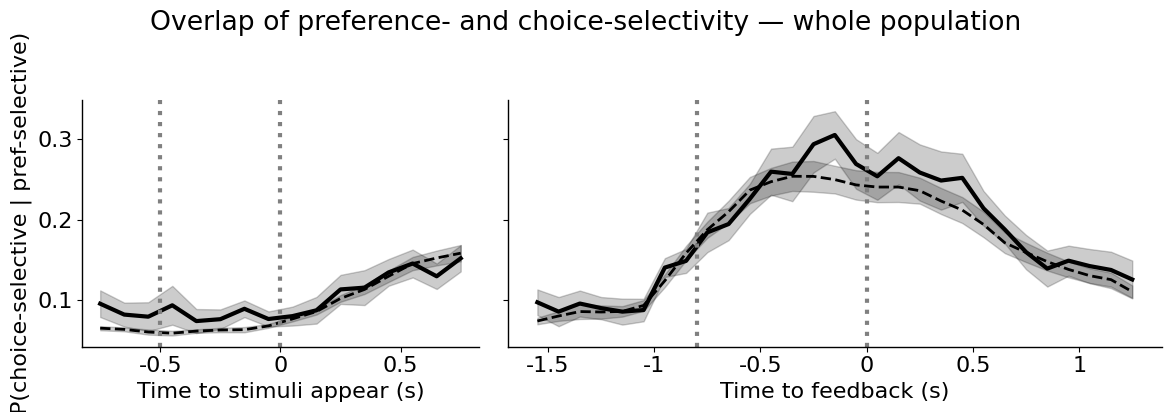

In [9]:
fig, _ = plot_by_time(
    overlap_all, "frac_pref_also_choice",
    ylabel="P(choice-selective | pref-selective)",
    chance_col="chance",
    title="Overlap of preference- and choice-selectivity \u2014 whole population",
)
plt.show()

### Split by region

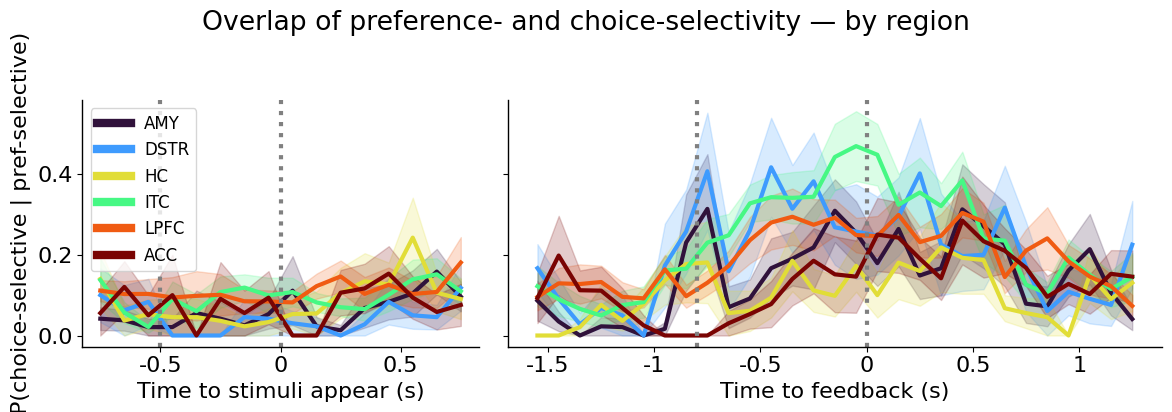

In [10]:
fig, _ = plot_by_time(
    overlap_region, "frac_pref_also_choice",
    ylabel="P(choice-selective | pref-selective)",
    hue_col="region",
    title="Overlap of preference- and choice-selectivity \u2014 by region",
)
plt.show()

#### Same thing, pooled across features instead of averaged

The per-region denominators are small (see the table above), so a mean of 12 noisy ratios is
unstable. Pooling the counts across features first and then taking one ratio is the same quantity
with much less variance -- but note the shaded band is a binomial interval that assumes independent
units, so it is optimistic.

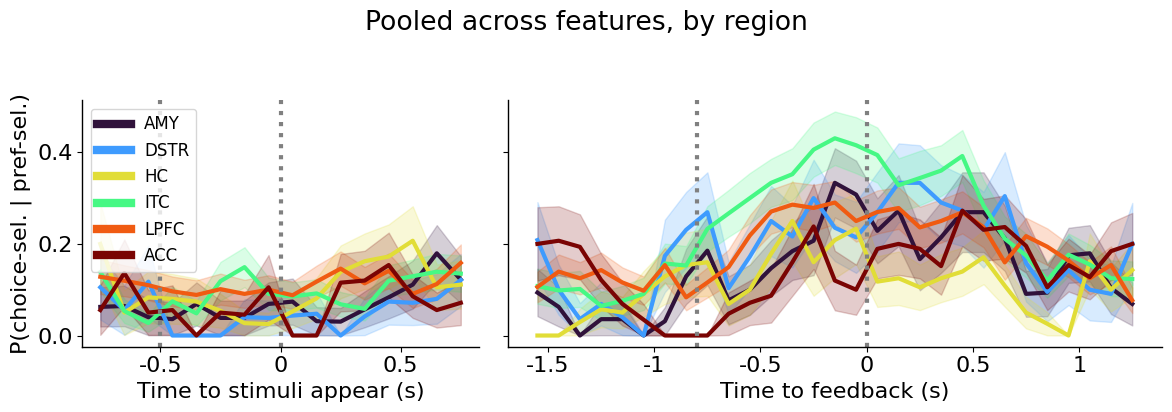

In [11]:
pooled = (overlap_region.groupby(["trial_event", "WindowEndMilli", "structure_level2_cleaned"])
          [["n_both", "n_pref", "n_choice", "n_units"]].sum().reset_index())
pooled["frac_pref_also_choice"] = pooled["n_both"] / pooled["n_pref"].replace(0, np.nan)
pooled["chance"] = pooled["n_choice"] / pooled["n_units"]
pooled["Time"] = pooled["WindowEndMilli"] / 1000 - WINDOW_SIZE / 2000
pooled["region"] = pooled["structure_level2_cleaned"].map(visualization_utils.REGION_TO_ABBREV)
p = pooled["frac_pref_also_choice"]
pooled["se"] = np.sqrt(p * (1 - p) / pooled["n_pref"].replace(0, np.nan))

hue_order = [r for r in visualization_utils.REGION_ORDER if r in set(pooled.region)]
fig, axs = plt.subplots(1, 2, figsize=(12, 4), sharey="row", width_ratios=[20, 33])
for i, event in enumerate(EVENTS):
    ax, cfg = axs[i], EVENT_CONFIG[event]
    d = pooled[pooled.trial_event == event]
    for region in hue_order:
        dr = d[d.region == region].sort_values("Time")
        color = visualization_utils.REGION_TO_COLOR[region]
        ax.plot(dr.Time, dr.frac_pref_also_choice, linewidth=3, color=color, label=region)
        ax.fill_between(dr.Time, dr.frac_pref_also_choice - dr.se,
                        dr.frac_pref_also_choice + dr.se, color=color, alpha=0.2)
    for v in cfg["vlines"]:
        ax.axvline(v, color="grey", linestyle="dotted", linewidth=3)
    ax.set_xlabel(cfg["xlabel"])
    ax.set_xticks(cfg["ticks"]); ax.set_xticklabels(cfg["ticks"])
    if i == 0:
        ax.set_ylabel("P(choice-sel. | pref-sel.)")
        for line in ax.legend(fontsize=12).get_lines():
            line.set_linewidth(6)
visualization_utils.format_plot(list(axs))
fig.suptitle("Pooled across features, by region", y=1.04)
fig.tight_layout()
plt.show()

### Context: the marginals, and overlap relative to chance

The conditional above moves with both marginals, so it can't be compared across regions on its own.
These two panels are what make it interpretable: the marginal selectivity rates that drive it, and
the observed/expected ratio (1.0 = independent).

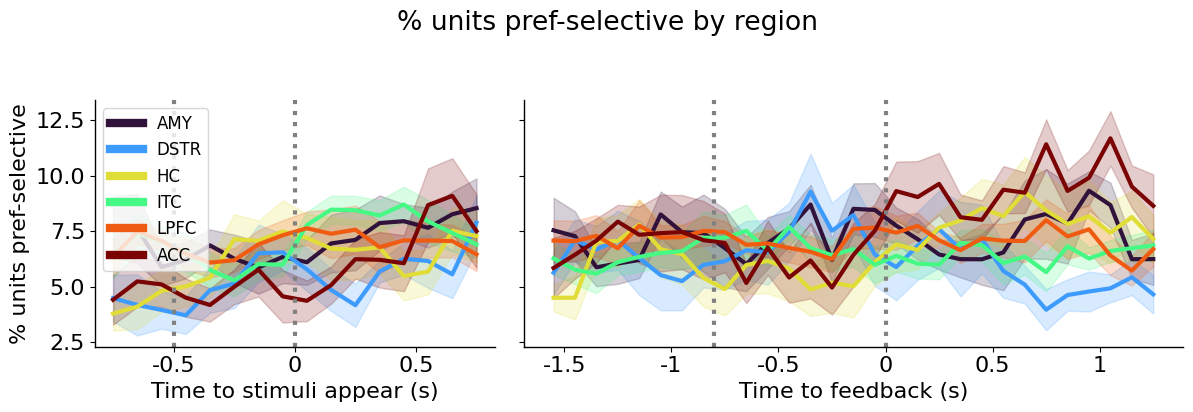

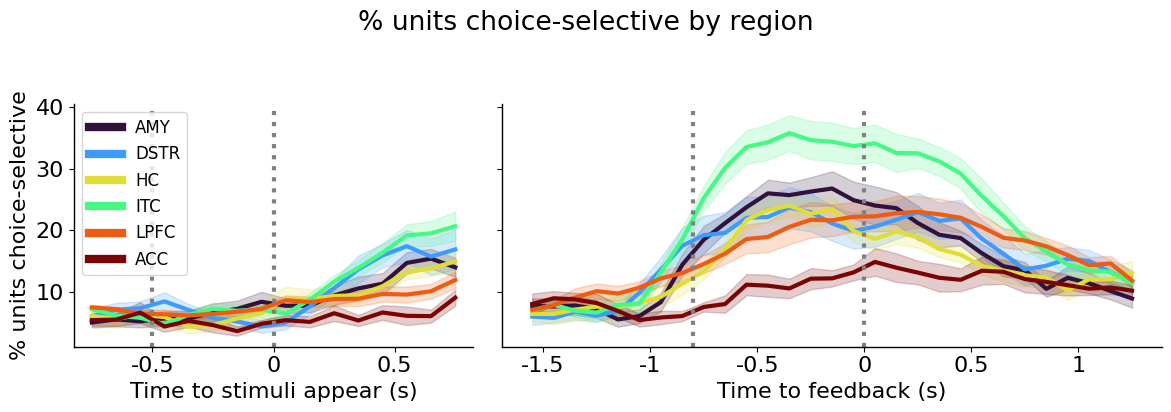

In [12]:
for col, label in [("frac_pref", "% units pref-selective"), ("frac_choice", "% units choice-selective")]:
    plot_df = overlap_region.copy()
    plot_df[col] = plot_df[col] * 100
    fig, _ = plot_by_time(plot_df, col, ylabel=label, hue_col="region", title=label + " by region")
    plt.show()

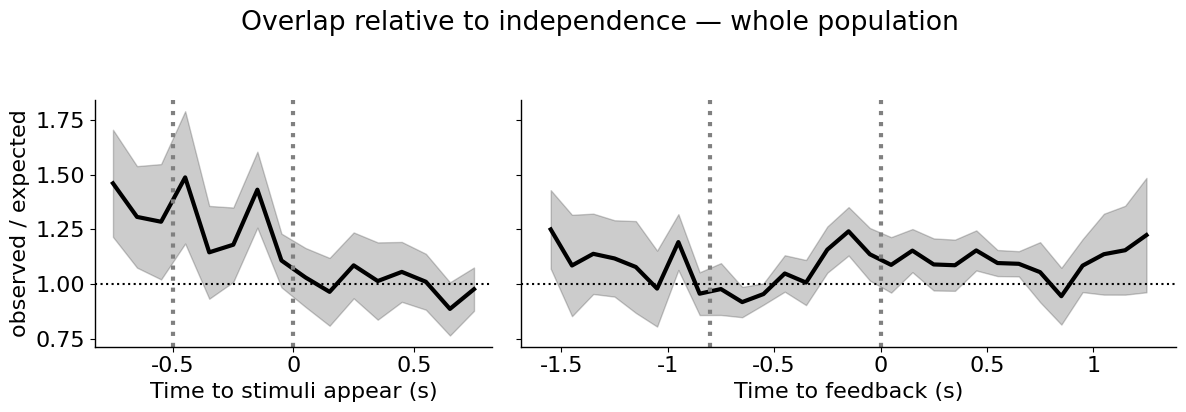

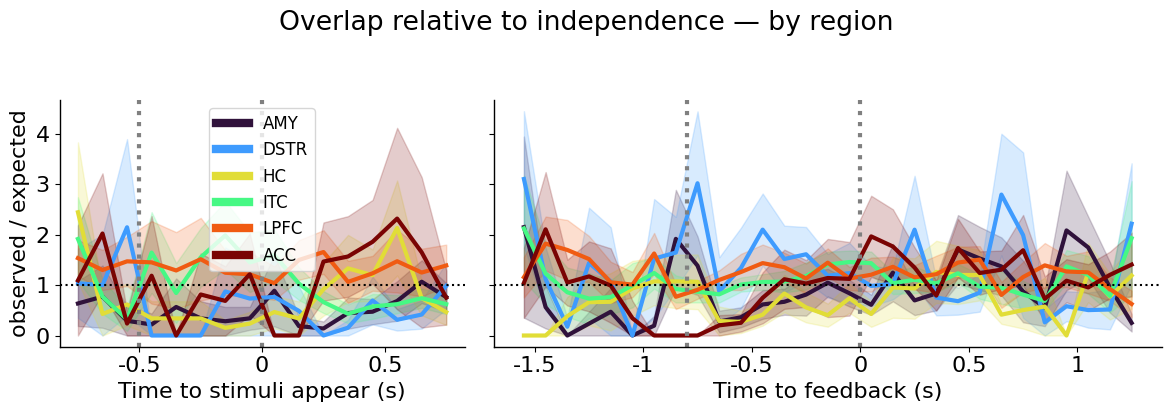

In [13]:
fig, axs = plot_by_time(
    overlap_all, "obs_over_exp",
    ylabel="observed / expected",
    title="Overlap relative to independence \u2014 whole population",
)
for ax in axs:
    ax.axhline(1.0, color="black", linestyle="dotted")
plt.show()

fig, axs = plot_by_time(
    overlap_region, "obs_over_exp",
    ylabel="observed / expected",
    hue_col="region",
    title="Overlap relative to independence \u2014 by region",
)
for ax in axs:
    ax.axhline(1.0, color="black", linestyle="dotted")
plt.show()

---

## Caveats

These do not invalidate the plots, but they bound what the plots can be used to claim.

**1. The two selectivities are estimated on different trial sets.** The choice ANOVA uses all
trials; the preference ANOVA uses only `Response=Correct, Choice=Chose`. So they have different N
and therefore different detection power, and the preference set is biased toward
high-confidence, late-in-block states. `P(choice | pref)` inherits both.

**2. Belief is not in the choice ANOVA's model.** Choice and preferred belief are strongly
correlated behaviourally, so belief-driven variance loads onto the `Choice` factor. Part of the
measured overlap is that behavioural correlation rather than shared neural coding. Fixing this
needs one joint ANOVA (`--conditions Choice,BeliefDimPartition`, with balancing, since main
effects in `anova_factors` are marginal rather than partial).

**3. The unit of analysis is (unit, feature), not unit.** A cell can be pref-selective for CIRCLE
and choice-selective for STAR. Averaging over the 12 features as done here is the right level, but
the features are not independent samples -- the same cells recur across them -- so the s.e.m.
across features understates the true uncertainty.

**4. `BeliefPref` is a derived difference,** `x_BeliefPartition - x_BeliefConf`, not a model term.
It is noisier than `Choice` and can go negative. That noise asymmetry means
`P(choice | pref)` and `P(pref | choice)` are not comparable to each other.

**5. The 99th percentile comes from ~100 shuffles,** so the threshold is close to the maximum of
100 samples -- a noisy, biased quantile. Re-run with `SIG_THRESH = "95th"`; if the picture changes
qualitatively, threshold noise is driving it.

**6. Windows overlap.** `run_anova.py` steps by 100 ms with a 500 ms window, so adjacent points
share 80% of their data. Fine for plotting, but no test that assumes independent timepoints.

**7. Binarising discards most of the signal, and all of the sign.** Fracvar is a variance, so two
units can both be "selective for both" while pushing in opposite directions. The signed version --
per-unit standardised mean differences for each contrast, correlated across units -- gives the same
figure plus the geometry, and is the analysis recommended in
`claude_notes/weight_vs_mean_difference_axes.md` section 7.

**8. Chance here is the independence null.** A stronger null is available: recompute the statistic
on the existing ANOVA shuffle runs, which inherit the correct marginals, N, and cell structure.